In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Bài 1

## 1.1 Biến dữ liệu thành ma trận

In [2]:
pictures = ['anh1.jpeg', 'anh2.jpeg', 'anh3.jpeg', 'anh4.jpeg','anh5.jpeg',
       'anh6.jpeg', 'anh7.jpeg', 'anh8.jpeg']
X = []
for pic in pictures:
    anh = np.array(Image.open(pic).convert('L').resize((256, 256)), dtype = float)
    anh = anh.reshape(-1)
    X.append(anh)
X = np.array(X)
X.shape

(8, 65536)

Con số 8 đại diện cho số lượng bức ảnh xám trong tập dữ liệu thử nghiệm.

Con số 65,536 là tổng số pixel của mỗi bức ảnh sau khi đã được chuẩn hóa kích thước (resize) về dạng vuông $256 \times 256$ và duỗi phẳng (flatten) thành một vector hàng 1 chiều ($256 \times 256 = 65,536$).

## 1.2 Phép toán cơ bản

In [3]:
avg = np.mean(X, axis = 0, keepdims= True)
print(f"Shape của avg và X trước khi trừ là: {avg.shape}, {X.shape}")
X = X - avg
print(f"Shape của avg và X sau khi trừ là: {avg.shape}, {X.shape}")


Shape của avg và X trước khi trừ là: (1, 65536), (8, 65536)
Shape của avg và X sau khi trừ là: (1, 65536), (8, 65536)


## 1.3 Cosine similarity

In [4]:
def cosine_similarity(X, Y = None):
    if Y is None:
        Y = X
    Xn = X/ np.linalg.norm(X, axis = 1, keepdims= True)
    Yn = Y/ np.linalg.norm(Y, axis = 1, keepdims=True)
    return Xn @ Yn.T

## 1.4 Truy Vấn

In [5]:
def search(query, top_k = 3):
    result = []
    for i in range(len(X)):
        result.append((i, cosine_similarity(X[i].reshape(1,-1), query.reshape(1, -1))))
    result.sort(key = lambda x: x[1], reverse=True)
    return result[:top_k]

In [6]:
query = np.array(Image.open('query.jpeg').convert('L').resize((256,256)), dtype = 'float')
query = query.reshape(-1) - avg.reshape(-1)
top_k = search(query)
for i in range(3):
    print(f'Ảnh giống thứ {i+1} là ảnh: {top_k[i][0] + 1} với độ phù hợp {top_k[i][1]}')

Ảnh giống thứ 1 là ảnh: 3 với độ phù hợp [[0.44914683]]
Ảnh giống thứ 2 là ảnh: 1 với độ phù hợp [[0.30187445]]
Ảnh giống thứ 3 là ảnh: 7 với độ phù hợp [[0.05823301]]


## 1.5 Nhận xét

Query là chó trắng trên nền cỏ xanh. Kết quả top 1 là ảnh 3 (máy bay nền trời xanh, 0.449) — sau khi xám hóa thì cả hai ảnh đều có nền sáng chiếm diện tích lớn, khiến phân bố pixel tương tự nhau. Ảnh 1 (chó ngậm hoa, 0.302) xếp thứ 2 — đây là kết quả có nghĩa nhất vì cùng là chó, nhưng lại bị xếp sau máy bay. Ảnh 7 (3 con mèo, 0.058) điểm rất thấp do nền cây tối hơn, phân bố pixel khác xa query.

Điều này một lần nữa minh họa rõ hạn chế của cosine similarity trên pixel thô: cùng loài động vật không đảm bảo pixel giống nhau, trong khi hai ảnh hoàn toàn khác nội dung lại có thể có phân bố sáng/tối tương tự. Trong AI thực tế, embedding từ CNN/ViT sẽ cho kết quả có ngữ nghĩa hơn nhiều.



# 2

## 2.1 Biến đổi tuyến tính


Một hình đơn giản:

In [7]:
def Xoay(goc, box): # box phải có kích thước 2xn
    theta = np.radians(goc)
    R = np.array([[np.cos(theta), -np.sin(theta)],
                  [np.sin(theta), np.cos(theta)]])
    return R@box

In [8]:
def CoGian(rong, cao, box):
    S = np.array([[rong, 0],
                  [0, cao]])
    return S@box

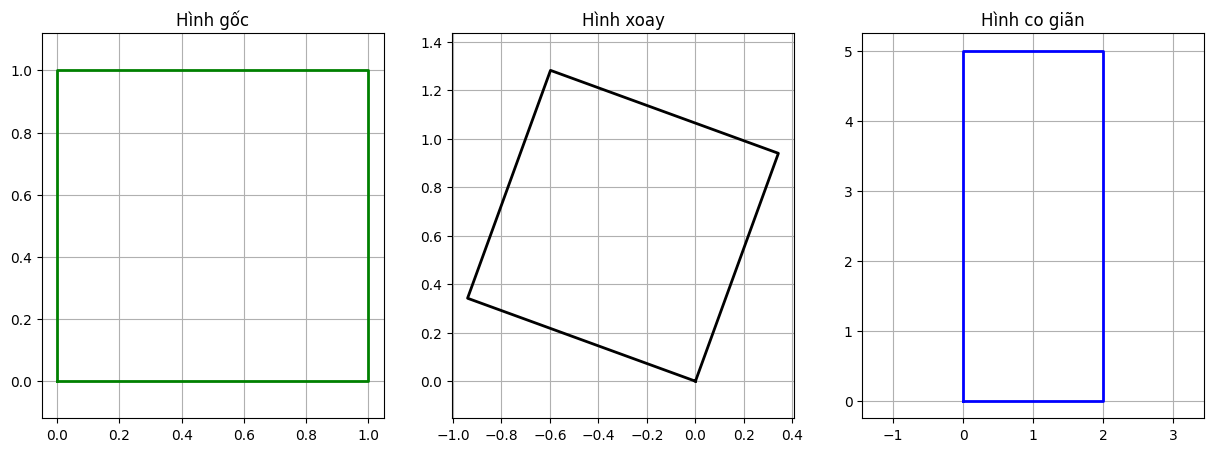

In [9]:
box = np.array([[0,1,1,0,0],
                [0,0,1,1,0]])
goc = 70
box_xoay = Xoay(goc, box)
box_co_gian = CoGian(2, 5, box)

plt.figure(figsize = (15, 5))

#hình 1
plt.subplot(1,3,1)
plt.plot(box[0], box[1], color ='green', linewidth = 2)
plt.title('Hình gốc')
plt.axis('equal')
plt.grid(True)

#hình 2
plt.subplot(1,3,2)
plt.plot(box_xoay[0], box_xoay[1], color ='black', linewidth = 2)
plt.title('Hình xoay')
plt.axis('equal')
plt.grid(True)

#hình 3
plt.subplot(1,3,3)
plt.plot(box_co_gian[0], box_co_gian[1], color ='blue', linewidth = 2)
plt.title('Hình co giãn')
plt.axis('equal')
plt.grid(True)

plt.show()


## 2.2 Nén ảnh bằng SVD

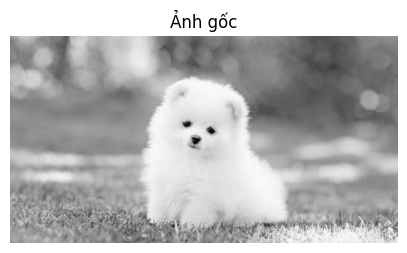

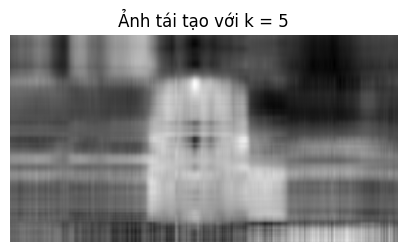

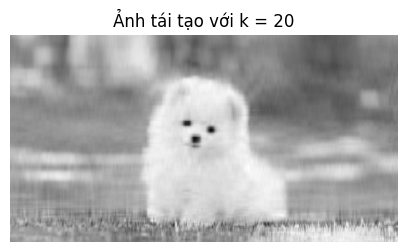

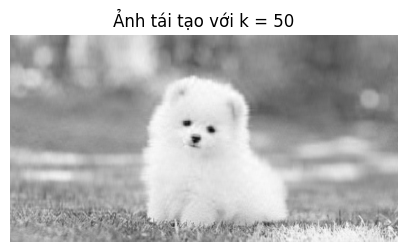

In [10]:
M = np.array(Image.open('query.jpeg').convert('L'), dtype = float)
plt.figure(figsize=(5, 5))
plt.imshow(M, cmap='gray')
plt.title("Ảnh gốc")
plt.axis('off')
plt.show()
U, S, Vt = np.linalg.svd(M, full_matrices=False)
ks = [5, 20, 50]
def reconstruct(k):
    return (U[:, :k] * S[:k]) @ Vt[:k, :]
for k in ks:
    M_k = reconstruct(k)
    plt.figure(figsize=(5, 5))
    plt.imshow(M_k, cmap='gray')
    plt.title(f"Ảnh tái tạo với k = {k}")
    plt.axis('off')
    plt.show()


## 2.3 Đánh giá

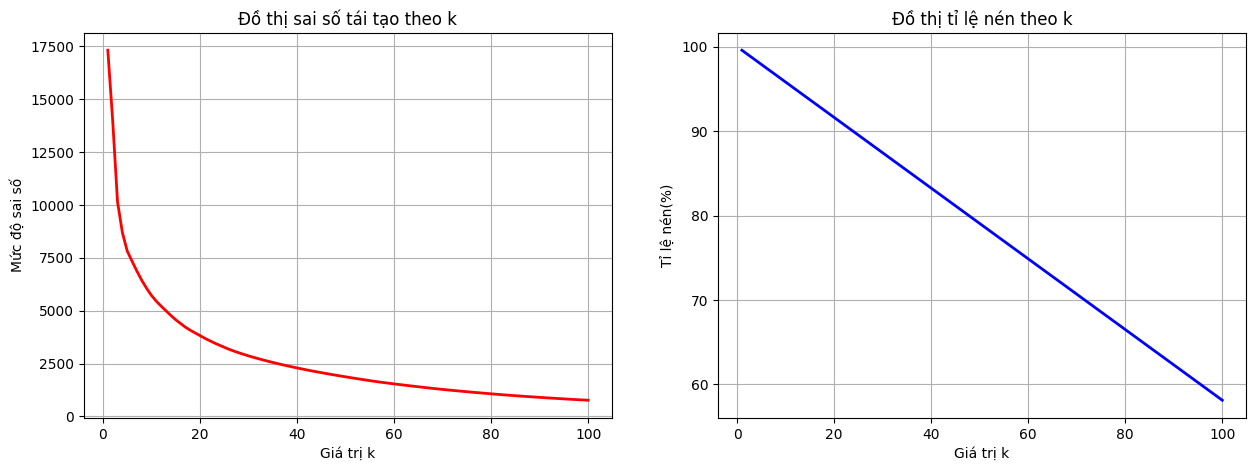

In [11]:
danh_sach_sai_so = []
ti_le_nen = []
H, W = M.shape
goc = H*W
k_khao_sat = range(1, 101)
for k in k_khao_sat:
    M_k = reconstruct(k)
    sai_so = np.linalg.norm(M - M_k)
    danh_sach_sai_so.append(sai_so)
    nen = k*(H + W + 1)
    ti_le = (1 - nen/goc) * 100
    ti_le_nen.append(ti_le)

plt.figure(figsize=(15,5))
# sai số tái tạo
plt.subplot(1,2,1)
plt.plot(k_khao_sat, danh_sach_sai_so, color = 'red', linewidth = 2)
plt.title('Đồ thị sai số tái tạo theo k')
plt.xlabel('Giá trị k')
plt.ylabel('Mức độ sai số')
plt.grid(True)

# tỉ lệ nén
plt.subplot(1,2,2)
plt.plot(k_khao_sat, ti_le_nen, color = 'blue', linewidth = 2)
plt.title('Đồ thị tỉ lệ nén theo k')
plt.xlabel('Giá trị k')
plt.ylabel('Tỉ lệ nén(%)')
plt.grid(True)

plt.show()


## Năng lượng tích luỹ

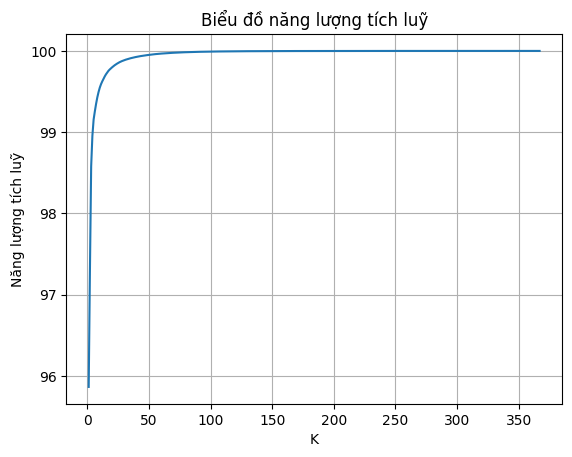

In [12]:
energy = S**2
nang_luong_tich_luy = np.cumsum(energy)/np.sum(energy) * 100

plt.plot(range(1, len(S) + 1), nang_luong_tich_luy)
plt.title('Biểu đồ năng lượng tích luỹ')
plt.xlabel('K')
plt.ylabel('Năng lượng tích luỹ')
plt.grid(True)
plt.show()

In [13]:
k_90 = np.argmax(nang_luong_tich_luy >= 90) + 1
print(f'Vậy cần chọn giữ k = {k_90} để năng lượng tích luỹ >= 90%')

Vậy cần chọn giữ k = 1 để năng lượng tích luỹ >= 90%


## 2.4 Nhận xét

- **Sai số**: giảm nhanh khi k tăng từ 1 đến ~20, sau đó chậm dần — phần lớn thông
  tin ảnh nằm ở các singular values đầu tiên. 
- **Tỉ lệ nén**: với k=5 chỉ cần lưu ~5.5% dữ liệu gốc, ảnh đã nhận ra được nhưng
  còn mờ; k=20–50 cho ảnh chấp nhận được với dung lượng nhỏ hơn nhiều.
- **Ngưỡng 90%**: chỉ cần giữ k = 1 singular values là đủ 90% thông tin — minh
  họa rõ nguyên lý **giảm chiều (dimensionality reduction)**: dữ liệu thực tế thường
  có cấu trúc thấp chiều ẩn.
- **Liên hệ AI**: SVD/PCA dùng để giảm chiều đặc trưng trước khi đưa vào mô hình,
  giúp giảm overfitting và tăng tốc độ huấn luyện.